In [51]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon

In [52]:
# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Base conditon\10-yr return period storm.m21fm - Result Files\area_10yr_base_stat.dfsu"
data = ds.read(items="Statistical maximum : Total water depth") 


In [53]:
# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)


In [54]:
# Extract geometry information
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates  # This gets the node coordinates
element_table

array([array([29698,  8289, 10972]), array([18888, 21252, 11501]),
       array([57688, 28834,  7824]), ..., array([ 50690, 101839,  91736]),
       array([ 98136, 101840,  64873]), array([ 64904, 101840, 101740])],
      dtype=object)

In [55]:
# Get water depth data
water_depth = data[0].to_numpy()
water_depth

array([[0.       , 4.8858337, 8.743414 , ..., 5.246943 , 4.2314496,
        4.1664696]], dtype=float32)

In [56]:

# Define the threshold value
threshold = 0.1  # meters

In [57]:
# Identify elements where water depth exceeds the threshold
flooded_elements = np.where(water_depth > threshold)[1]

In [58]:
flooded_elements

array([     1,      2,      3, ..., 203085, 203086, 203087], dtype=int64)

In [59]:
nodes = element_table[203087]  # zero-index correction
coords = node_coordinates[nodes]
coords

array([[ 6.60250121e+05,  3.02445004e+06, -9.87099290e-01],
       [ 6.60111906e+05,  3.02456240e+06, -1.03213358e+00],
       [ 6.60070806e+05,  3.02439486e+06, -1.20012784e+00]])

In [60]:
# Create polygons for flooded elements
flooded_polygons = []
for elem_idx in flooded_elements:
  #print(elem_idx)
  nodes = element_table[elem_idx]  # zero-index correction
  coords = node_coordinates[nodes]
  flooded_polygons.append(Polygon(coords))
#flooded_polygons
# Convert polygons to a GeoDataFrame
flooded_area_gdf = gpd.GeoDataFrame(
    {'geometry': flooded_polygons},
    crs="EPSG:32614"  # UTM Zone 14N
)


<AxesSubplot: >

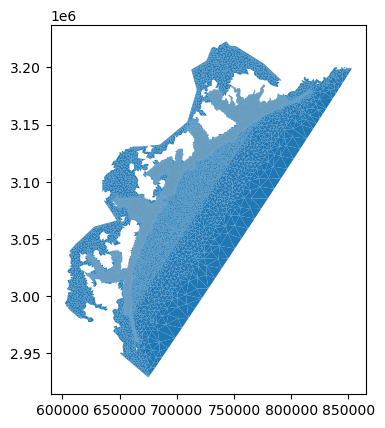

In [44]:
flooded_area_gdf.plot()

In [61]:
flooded_area_gdf_ds = flooded_area_gdf.dissolve()

<AxesSubplot: >

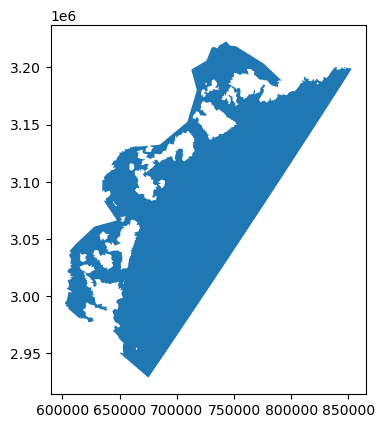

In [62]:
flooded_area_gdf_ds.plot()

In [47]:


# Clip the flooded areas with the land boundary
flooded_area_intersect = gpd.overlay(flooded_area_gdf_ds, land_boundary, how='intersection')


# Calculate the total flooded area (in square meters)
total_flooded_area = flooded_area_intersect.area

# Convert to square kilometers (if needed)
total_flooded_area_km2 = total_flooded_area / 1e6

#print(f"Total flooded area: {total_flooded_area_km2:.2f} square kilometers")

In [63]:
total_flooded_area_km2

0    7848.315591
dtype: float64

<AxesSubplot: >

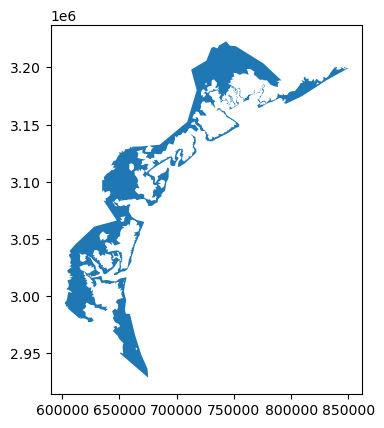

In [64]:
flooded_area_intersect.plot()